# **LAB 03 - LAB TOKENIZER**
**Sinh viên:** Nguyễn Văn Anh Duy  
**MSSV:** SE181823  
**Lớp:** AI1803

---
**Yêu cầu:** 

- Nộp dưới dạng link drive chứa file notebook, không cần nộp dataset theo kèm.
- Yêu cầu file notebook phải debug thành công


## Import Thư viện

Phần này import các thư viện cần thiết cho bài lab:

In [ ]:
# json: Xử lý file JSON, đọc dataset Sarcasm Headlines
import json

# numpy: Thư viện tính toán số học, xử lý mảng và ma trận
import numpy as np

# matplotlib.pyplot: Vẽ biểu đồ, trực quan hóa dữ liệu
import matplotlib.pyplot as plt

# seaborn: Thư viện vẽ biểu đồ thống kê đẹp mắt, mở rộng matplotlib
import seaborn as sns

# Tokenizer: Chuyển đổi văn bản thành sequences (chuỗi số)
from tensorflow.keras.preprocessing.text import Tokenizer

# pad_sequences: Chuẩn hóa độ dài sequences (padding)
from tensorflow.keras.preprocessing.sequence import pad_sequences

# re: Regular expression, xử lý chuỗi và pattern matching
import re

# string: Cung cấp constants và functions để xử lý chuỗi
import string

# Counter: Đếm tần suất xuất hiện của phần tử trong collection
from collections import Counter

## Đọc và Chuẩn bị Dữ liệu

In [ ]:
# Đường dẫn đến file dataset
file_path = "../LAB_Slot_09_Vector_Hóa_Chuỗi_Ký_Tự/Sarcasm_Headlines_Dataset_v2.json"

# Khởi tạo list để lưu dữ liệu
articles = []
labels = []

# Đọc file JSON và parse dữ liệu
with open(file_path, 'r') as f:
    for line in f:
        article = json.loads(line)
        articles.append(article['headline'])
        labels.append(article['is_sarcastic'])

# Chuyển thành list sentences để sử dụng cho các bài tập
sentences = articles

# Hiển thị thông tin dataset
print(f"Tổng số câu trong dataset: {len(sentences)}")
print(f"\nVí dụ 5 câu đầu tiên:")
for i in range(5):
    print(f"  {i+1}. {sentences[i]}")

Tổng số câu trong dataset: 28619
Ví dụ 5 câu đầu tiên:
  1. thirtysomething scientists unveil doomsday clock of hair loss
  2. dem rep. totally nails why congress is falling short on gender, racial equality
  3. eat your veggies: 9 deliciously different recipes
  4. inclement weather prevents liar from getting to work
  5. mother comes pretty close to using word 'streaming' correctly


---
## **BÀI 1: Phân tích Tỷ lệ Bao phủ Thông tin (Information Coverage Rate)**

**Mục tiêu:**
- Khởi tạo Tokenizer với `num_words=2000` và `oov_token="<OOV>"`
- Tính toán tỷ lệ bao phủ thông tin khi chỉ giữ lại 2000 từ quan trọng nhất
- Vẽ biểu đồ phân tích % từ bị mất (OOV) trên toàn bộ dataset

In [3]:
# Bài 1.1: Khởi tạo Tokenizer với num_words=2000 và oov_token
tokenizer_2000 = Tokenizer(num_words=2000, oov_token="<OOV>")
tokenizer_2000.fit_on_texts(sentences)

# Chuyển đổi sentences thành sequences
sequences_2000 = tokenizer_2000.texts_to_sequences(sentences)

print(f"Số từ trong word_index: {len(tokenizer_2000.word_index)}")
print(f"Số từ được giữ lại (num_words): 2000")
print(f"\nVí dụ 3 câu đầu tiên:")
for i in range(3):
    print(f"\nCâu gốc: {sentences[i]}")
    print(f"Sequence: {sequences_2000[i]}")

Số từ trong word_index: 30885
Số từ được giữ lại (num_words): 2000

Ví dụ 3 câu đầu tiên:

Câu gốc: thirtysomething scientists unveil doomsday clock of hair loss
Sequence: [1, 355, 1, 1, 1, 3, 661, 1119]

Câu gốc: dem rep. totally nails why congress is falling short on gender, racial equality
Sequence: [1, 1775, 758, 1, 47, 239, 11, 1844, 1048, 8, 1528, 1, 1845]

Câu gốc: eat your veggies: 9 deliciously different recipes
Sequence: [863, 33, 1, 262, 1, 647, 1484]


In [4]:
# Bài 1.2: Tính toán Tỷ lệ Bao phủ Thông tin (Information Coverage Rate)

# Lấy index của token OOV
oov_token_index = tokenizer_2000.word_index["<OOV>"]

# Biến đếm
total_words = 0  # Tổng số từ trong toàn bộ dataset
oov_words = 0    # Số từ bị thay thế bằng OOV
covered_words = 0  # Số từ được giữ lại

# Duyệt qua tất cả các câu
for i, sentence in enumerate(sentences):
    # Đếm số từ trong câu gốc
    words_in_sentence = sentence.lower().split()
    sentence_word_count = len(words_in_sentence)
    total_words += sentence_word_count
    
    # Đếm số OOV trong sequence tương ứng
    sequence = sequences_2000[i]
    oov_count_in_sequence = sequence.count(oov_token_index)
    oov_words += oov_count_in_sequence
    
    # Số từ được giữ lại = tổng từ trong sequence - số OOV
    covered_words += (len(sequence) - oov_count_in_sequence)

# Tính tỷ lệ phần trăm
oov_percentage = (oov_words / total_words) * 100
coverage_percentage = (covered_words / total_words) * 100

print("=" * 70)
print("PHÂN TÍCH TỶ LỆ BAO PHỦ THÔNG TIN")
print("=" * 70)
print(f"Tổng số từ trong dataset: {total_words:,}")
print(f"Số từ được giữ lại (covered): {covered_words:,}")
print(f"Số từ bị mất (OOV): {oov_words:,}")
print(f"\nTỷ lệ bao phủ thông tin: {coverage_percentage:.2f}%")
print(f"Tỷ lệ từ bị mất: {oov_percentage:.2f}%")
print("=" * 70)

PHÂN TÍCH TỶ LỆ BAO PHỦ THÔNG TIN
Tổng số từ trong dataset: 287,620
Số từ được giữ lại (covered): 203,207
Số từ bị mất (OOV): 90,482

Tỷ lệ bao phủ thông tin: 70.65%
Tỷ lệ từ bị mất: 31.46%


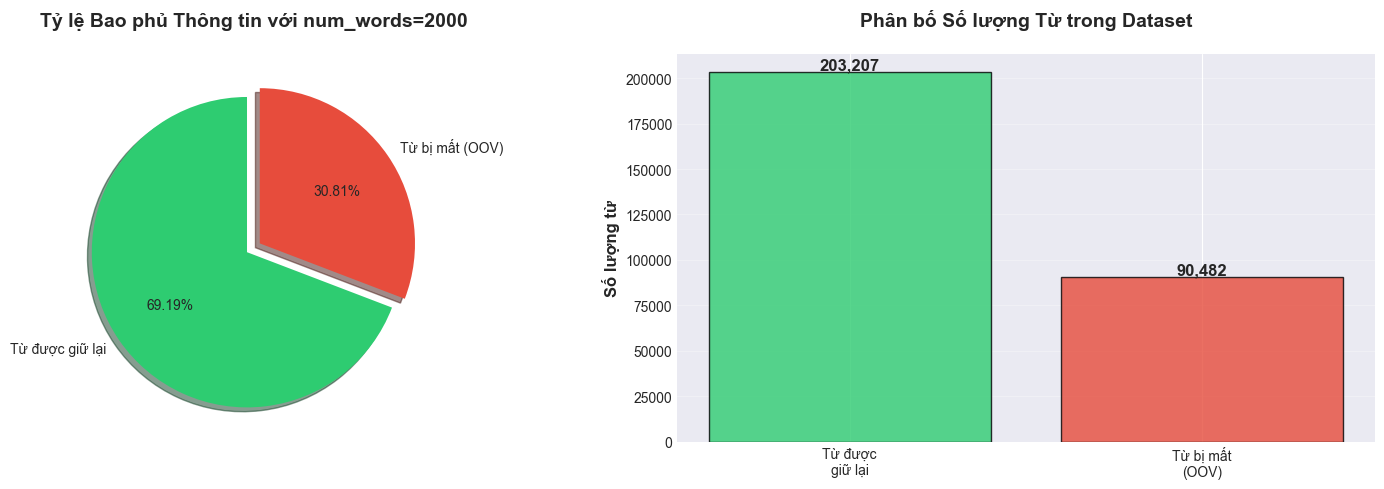


📊 THỐNG KÊ BỔ SUNG:
Trung bình số từ mỗi câu: 10.05
Trung bình số từ OOV mỗi câu: 3.16


In [ ]:
# Bài 1.3: Vẽ biểu đồ phân tích

# Thiết lập style cho biểu đồ
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ 1: Pie chart - Tỷ lệ phần trăm
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.05)
axes[0].pie([coverage_percentage, oov_percentage], 
            labels=['Từ được giữ lại', 'Từ bị mất (OOV)'],
            autopct='%1.2f%%',
            startangle=90,
            colors=colors,
            explode=explode,
            shadow=True)
axes[0].set_title('Tỷ lệ Bao phủ Thông tin với num_words=2000', 
                  fontsize=14, fontweight='bold', pad=20)

# Biểu đồ 2: Bar chart - Số lượng từ
categories = ['Từ được\ngiữ lại', 'Từ bị mất\n(OOV)']
values = [covered_words, oov_words]
bars = axes[1].bar(categories, values, color=colors, alpha=0.8, edgecolor='black')

# Thêm giá trị lên thanh bar
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[1].set_ylabel('Số lượng từ', fontsize=12, fontweight='bold')
axes[1].set_title('Phân bố Số lượng Từ trong Dataset', 
                  fontsize=14, fontweight='bold', pad=20)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Thống kê bổ sung
print("\n[THỐNG KÊ BỔ SUNG]")
print(f"Trung bình số từ mỗi câu: {total_words/len(sentences):.2f}")
print(f"Trung bình số từ OOV mỗi câu: {oov_words/len(sentences):.2f}")

---
## **BÀI 2: Tìm các Câu bị Hỏng (Corrupted Sentences)**

**Mục tiêu:**
- Khởi tạo Tokenizer KHÔNG có `oov_token` với `num_words=10000`
- Viết hàm `find_corrupted_sentences()` để tìm câu bị mất >30% từ
- In ra 5 ví dụ câu gốc và các từ còn lại sau tokenize

In [6]:
# Bài 2.1: Khởi tạo Tokenizer KHÔNG có oov_token
tokenizer_no_oov = Tokenizer(num_words=10000)  # Không có oov_token
tokenizer_no_oov.fit_on_texts(sentences)

# Chuyển đổi sentences thành sequences
sequences_no_oov = tokenizer_no_oov.texts_to_sequences(sentences)

print(f"Số từ trong word_index: {len(tokenizer_no_oov.word_index)}")
print(f"Số từ được giữ lại (num_words): 10000")
print(f"\nVí dụ: Khi không có oov_token, các từ lạ sẽ bị bỏ qua hoàn toàn")
print(f"Câu gốc: {sentences[0]}")
print(f"Sequence: {sequences_no_oov[0]}")

Số từ trong word_index: 30884
Số từ được giữ lại (num_words): 10000

Ví dụ: Khi không có oov_token, các từ lạ sẽ bị bỏ qua hoàn toàn
Câu gốc: thirtysomething scientists unveil doomsday clock of hair loss
Sequence: [354, 3166, 7473, 2643, 2, 660, 1118]


In [7]:
# Bài 2.2: Viết hàm find_corrupted_sentences

def find_corrupted_sentences(original_texts, sequences, tokenizer, threshold=0.3):
    """
    Tìm các câu bị hỏng (mất >30% từ)
    
    Args:
        original_texts: List các câu văn bản gốc
        sequences: List các sequences đã được tokenize
        tokenizer: Tokenizer object để decode
        threshold: Ngưỡng % từ bị mất (mặc định 0.3 = 30%)
    
    Returns:
        List các tuple (index, original_text, tokenized_words, lost_words, loss_percentage)
    """
    corrupted_sentences = []
    
    # Tạo reverse word index để decode
    reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}
    
    for idx, (text, sequence) in enumerate(zip(original_texts, sequences)):
        # Đếm số từ trong câu gốc
        original_words = text.lower().split()
        original_word_count = len(original_words)
        
        # Đếm số từ trong sequence (sau khi tokenize)
        tokenized_word_count = len(sequence)
        
        # Tính số từ bị mất
        lost_word_count = original_word_count - tokenized_word_count
        loss_percentage = (lost_word_count / original_word_count) if original_word_count > 0 else 0
        
        # Kiểm tra nếu mất >threshold% từ
        if loss_percentage > threshold:
            # Decode sequence để lấy các từ còn lại
            tokenized_words = [reverse_word_index.get(num, '?') for num in sequence]
            
            # Tìm các từ bị mất
            tokenized_words_set = set(tokenized_words)
            lost_words = [word for word in original_words if word not in tokenized_words_set]
            
            corrupted_sentences.append({
                'index': idx,
                'original': text,
                'tokenized_words': tokenized_words,
                'lost_words': lost_words,
                'loss_percentage': loss_percentage * 100
            })
    
    return corrupted_sentences

# Tìm các câu bị hỏng
corrupted = find_corrupted_sentences(sentences, sequences_no_oov, tokenizer_no_oov)

print(f"Tổng số câu bị hỏng (mất >30% từ): {len(corrupted)}")
print(f"Tỷ lệ câu bị hỏng: {len(corrupted)/len(sentences)*100:.2f}%")

Tổng số câu bị hỏng (mất >30% từ): 1637
Tỷ lệ câu bị hỏng: 5.72%


In [ ]:
# Bài 2.3: In ra 5 ví dụ câu bị hỏng

print("\n" + "="*100)
print("5 VÍ DỤ CÂU BỊ HỎNG (CORRUPTED SENTENCES)")
print("="*100 + "\n")

# Lấy 5 ví dụ đầu tiên
for i, item in enumerate(corrupted[:5], 1):
    print(f"[VÍ DỤ {i}]")
    print(f"Original: \"{item['original']}\"")
    print(f"Tokenized Words: {item['tokenized_words']}")
    print(f"Lost Words: {item['lost_words']}")
    print(f"Status: CORRUPTED (Lost {len(item['lost_words'])} words, {item['loss_percentage']:.2f}%)")
    print("-" * 100 + "\n")


5 VÍ DỤ CÂU BỊ HỎNG (CORRUPTED SENTENCES)

📌 VÍ DỤ 1:
Original: "my white inheritance"
Tokenized Words: ['my', 'white']
Lost Words: ['inheritance']
Status: CORRUPTED (Lost 1 words, 33.33%)
----------------------------------------------------------------------------------------------------

📌 VÍ DỤ 2:
Original: "beyoncé sculpted in cheese is strangely alluring"
Tokenized Words: ['beyoncé', 'in', 'cheese', 'is']
Lost Words: ['sculpted', 'strangely', 'alluring']
Status: CORRUPTED (Lost 3 words, 42.86%)
----------------------------------------------------------------------------------------------------

📌 VÍ DỤ 3:
Original: "handshake comes in at unusually high angle, velocity"
Tokenized Words: ['comes', 'in', 'at', 'high']
Lost Words: ['handshake', 'unusually', 'angle,', 'velocity']
Status: CORRUPTED (Lost 4 words, 50.00%)
----------------------------------------------------------------------------------------------------

📌 VÍ DỤ 4:
Original: "brutalist beaver constructs paul rudolph-in

---
## **BÀI 3: Giải mã Sequence (Decode Sequence)**

**Mục tiêu:**
- Viết hàm `decode_sequence()` để chuyển đổi sequence (list số) về văn bản gốc
- Xử lý các trường hợp đặc biệt: số 0, token OOV
- Áp dụng decode sequence tại index 100

In [ ]:
# Bài 3: Viết hàm decode_sequence

def decode_sequence(sequence, tokenizer):
    """
    Giải mã sequence (list số) về văn bản gốc
    
    Args:
        sequence: List các số nguyên (một dòng trong sequences)
        tokenizer: Tokenizer object đã được fit
    
    Returns:
        decoded_text: Chuỗi văn bản đã được giải mã
    """
    # Tạo reverse word index: {số: từ}
    reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}
    
    # Giải mã từng số trong sequence
    decoded_words = []
    for num in sequence:
        if num == 0:
            # Bỏ qua padding (số 0)
            continue
        else:
            # Lấy từ tương ứng, nếu không có thì dùng '<UNKNOWN>'
            word = reverse_word_index.get(num, '<UNKNOWN>')
            decoded_words.append(word)
    
    # Ghép các từ lại thành câu
    decoded_text = ' '.join(decoded_words)
    return decoded_text

# Test hàm với tokenizer đã có oov_token (từ Bài 1)
print("="*80)
print("DEMO HÀM DECODE_SEQUENCE")
print("="*80)

# Test với 3 ví dụ
for i in range(3):
    original = sentences[i]
    sequence = sequences_2000[i]
    decoded = decode_sequence(sequence, tokenizer_2000)
    
    print(f"\n[Ví dụ {i+1}]")
    print(f"Câu gốc:  {original}")
    print(f"Sequence: {sequence[:10]}{'...' if len(sequence) > 10 else ''}")
    print(f"Decoded:  {decoded}")

DEMO HÀM DECODE_SEQUENCE

📝 Ví dụ 1:
Câu gốc:  thirtysomething scientists unveil doomsday clock of hair loss
Sequence: [1, 355, 1, 1, 1, 3, 661, 1119]
Decoded:  <OOV> scientists <OOV> <OOV> <OOV> of hair loss

📝 Ví dụ 2:
Câu gốc:  dem rep. totally nails why congress is falling short on gender, racial equality
Sequence: [1, 1775, 758, 1, 47, 239, 11, 1844, 1048, 8]...
Decoded:  <OOV> rep totally <OOV> why congress is falling short on gender <OOV> equality

📝 Ví dụ 3:
Câu gốc:  eat your veggies: 9 deliciously different recipes
Sequence: [863, 33, 1, 262, 1, 647, 1484]
Decoded:  eat your <OOV> 9 <OOV> different recipes


In [ ]:
# Bài 3.1: Áp dụng decode_sequence tại index 100

print("\n" + "="*80)
print("GIẢI MÃ SEQUENCE TẠI INDEX 100")
print("="*80)

# Lấy dữ liệu tại index 100
index_to_decode = 100
original_sentence = sentences[index_to_decode]
sequence_at_100 = sequences_2000[index_to_decode]
decoded_sentence = decode_sequence(sequence_at_100, tokenizer_2000)

print(f"\n[Chi tiết tại index {index_to_decode}]")
print(f"\nCâu gốc:")
print(f"  {original_sentence}")
print(f"\nSequence (các số):")
print(f"  {sequence_at_100}")
print(f"\nCâu đã decode:")
print(f"  {decoded_sentence}")

# So sánh độ dài
print(f"\n[Thống kê]")
print(f"  - Số từ trong câu gốc: {len(original_sentence.split())}")
print(f"  - Độ dài sequence: {len(sequence_at_100)}")
print(f"  - Số từ sau decode: {len(decoded_sentence.split())}")


GIẢI MÃ SEQUENCE TẠI INDEX 100

🔍 Chi tiết tại index 100:

Câu gốc:
  report: 70% of trump endorsements made after staring at bedroom ceiling for 4 hours

Sequence (các số):
  [40, 1, 3, 13, 1, 208, 19, 1, 15, 1, 1, 6, 189, 489]

Câu đã decode:
  report <OOV> of trump <OOV> made after <OOV> at <OOV> <OOV> for 4 hours

📊 Thống kê:
  - Số từ trong câu gốc: 14
  - Độ dài sequence: 14
  - Số từ sau decode: 14


---
## **BÀI 4: Xây dựng MyLiteTokenizer (Tokenizer tự làm)**

**Mục tiêu:**
- Viết class `MyLiteTokenizer` bằng Python thuần, KHÔNG dùng thư viện Keras
- Implement các method: `fit_on_texts()` và `texts_to_sequences()`
- So sánh kết quả với Keras Tokenizer để kiểm tra độ chính xác

In [ ]:
# Bài 4: Xây dựng MyLiteTokenizer

import re
import string
from collections import Counter

class MyLiteTokenizer:
    """
    Tokenizer tự làm bằng Python thuần, không sử dụng thư viện Keras
    """
    
    def __init__(self, num_words=None):
        """
        Khởi tạo tokenizer
        
        Args:
            num_words: Số lượng từ tối đa muốn giữ lại (giữ top từ phổ biến nhất)
        """
        self.num_words = num_words
        self.word_index = {}      # Dictionary: {từ: index}
        self.word_counts = {}     # Dictionary: {từ: tần suất}
    
    def fit_on_texts(self, texts):
        """
        Fit tokenizer trên danh sách các văn bản
        Xây dựng word_index và word_counts
        
        Args:
            texts: List các câu văn bản
        """
        # Bước 1: Đếm tần suất xuất hiện của mỗi từ
        for text in texts:
            # Chuẩn hóa: chuyển về lowercase
            text = text.lower()
            
            # Loại bỏ dấu câu (punctuation)
            # Tạo translation table để loại bỏ dấu câu
            translator = str.maketrans('', '', string.punctuation)
            text = text.translate(translator)
            
            # Tách từ theo khoảng trắng
            words = text.split()
            
            # Đếm tần suất
            for word in words:
                if word:  # Bỏ qua chuỗi rỗng
                    self.word_counts[word] = self.word_counts.get(word, 0) + 1
        
        # Bước 2: Sắp xếp từ theo tần suất giảm dần
        sorted_words = sorted(self.word_counts.items(), 
                            key=lambda x: x[1], 
                            reverse=True)
        
        # Bước 3: Xây dựng word_index
        # Chỉ giữ lại top num_words từ (nếu num_words được set)
        if self.num_words:
            sorted_words = sorted_words[:self.num_words]
        
        # Gán index cho mỗi từ (bắt đầu từ 1, giống Keras)
        for idx, (word, count) in enumerate(sorted_words, start=1):
            self.word_index[word] = idx
        
        print(f"[HOÀN THÀNH] Đã fit trên {len(texts)} văn bản")
        print(f"Tổng số từ unique: {len(self.word_counts)}")
        print(f"Số từ trong word_index: {len(self.word_index)}")
    
    def texts_to_sequences(self, texts):
        """
        Chuyển đổi list văn bản thành list sequences (list of integers)
        
        Args:
            texts: List các câu văn bản
            
        Returns:
            sequences: List các sequence (mỗi sequence là list số nguyên)
        """
        sequences = []
        
        for text in texts:
            # Chuẩn hóa giống như trong fit_on_texts
            text = text.lower()
            translator = str.maketrans('', '', string.punctuation)
            text = text.translate(translator)
            words = text.split()
            
            # Chuyển mỗi từ thành số (index)
            sequence = []
            for word in words:
                if word in self.word_index:
                    sequence.append(self.word_index[word])
                # Nếu từ không có trong word_index thì bỏ qua (giống hành vi Keras mặc định)
            
            sequences.append(sequence)
        
        return sequences

# Test MyLiteTokenizer
print("="*80)
print("TEST MYLITETOKENIZER")
print("="*80)

TEST MYLITETOKENIZER


In [ ]:
# Bài 4.1: Test MyLiteTokenizer với num_words=100

# Khởi tạo MyLiteTokenizer
my_tokenizer = MyLiteTokenizer(num_words=100)
my_tokenizer.fit_on_texts(sentences)

# Chuyển đổi thành sequences
my_sequences = my_tokenizer.texts_to_sequences(sentences)

print(f"\n[KẾT QUẢ]")
print(f"Số sequences: {len(my_sequences)}")
print(f"\nVí dụ 3 sequences đầu tiên từ MyLiteTokenizer:")
for i in range(3):
    print(f"\nCâu {i+1}: {sentences[i]}")
    print(f"Sequence: {my_sequences[i]}")

✅ Đã fit trên 28619 văn bản
📚 Tổng số từ unique: 29667
🔢 Số từ trong word_index: 100

📋 Kết quả:
Số sequences: 28619

Ví dụ 3 sequences đầu tiên từ MyLiteTokenizer:

Câu 1: thirtysomething scientists unveil doomsday clock of hair loss
Sequence: [2]

Câu 2: dem rep. totally nails why congress is falling short on gender, racial equality
Sequence: [46, 10, 7]

Câu 3: eat your veggies: 9 deliciously different recipes
Sequence: [34]


In [ ]:
# Bài 4.2: So sánh với Keras Tokenizer

print("\n" + "="*80)
print("SO SÁNH MYLITETOKENIZER VỚI KERAS TOKENIZER")
print("="*80)

# Tạo Keras Tokenizer để so sánh (không có oov_token, giống MyLiteTokenizer)
keras_tokenizer = Tokenizer(num_words=100)
keras_tokenizer.fit_on_texts(sentences)
keras_sequences = keras_tokenizer.texts_to_sequences(sentences)

# So sánh kết quả
print(f"\n[So sánh word_index]")
print(f"MyLiteTokenizer: {len(my_tokenizer.word_index)} từ")
print(f"Keras Tokenizer: {len(keras_tokenizer.word_index)} từ")

# So sánh 10 từ đầu tiên trong word_index
print(f"\n[Top 10 từ và index]")
print(f"{'STT':<5} {'Từ':<20} {'MyLite Index':<15} {'Keras Index':<15}")
print("-" * 60)

my_top_10 = list(my_tokenizer.word_index.items())[:10]
for i, (word, my_idx) in enumerate(my_top_10, 1):
    keras_idx = keras_tokenizer.word_index.get(word, 'N/A')
    match = "[OK]" if my_idx == keras_idx else "[X]"
    print(f"{i:<5} {word:<20} {my_idx:<15} {keras_idx:<15} {match}")


SO SÁNH MYLITETOKENIZER VỚI KERAS TOKENIZER

🔍 So sánh word_index:
MyLiteTokenizer: 100 từ
Keras Tokenizer: 30884 từ

📖 Top 10 từ và index:
STT   Từ                   MyLite Index    Keras Index    
------------------------------------------------------------
1     to                   1               1               ✅
2     of                   2               2               ✅
3     the                  3               3               ✅
4     in                   4               4               ✅
5     for                  5               5               ✅
6     a                    6               6               ✅
7     on                   7               7               ✅
8     and                  8               8               ✅
9     with                 9               9               ✅
10    is                   10              10              ✅


In [ ]:
# Bài 4.3: So sánh sequences chi tiết

print("\n" + "="*80)
print("SO SÁNH SEQUENCES")
print("="*80)

# So sánh 5 sequences đầu tiên
matching_count = 0
total_sequences = min(5, len(my_sequences))

for i in range(total_sequences):
    my_seq = my_sequences[i]
    keras_seq = keras_sequences[i]
    is_match = my_seq == keras_seq
    
    if is_match:
        matching_count += 1
    
    print(f"\n[Câu {i+1}] {sentences[i][:60]}...")
    print(f"MyLite:  {my_seq}")
    print(f"Keras:   {keras_seq}")
    print(f"Match: {'[Khớp]' if is_match else '[Không khớp]'}")

# Thống kê tổng quan
all_match = sum(1 for my_seq, keras_seq in zip(my_sequences[:100], keras_sequences[:100]) 
                if my_seq == keras_seq)
print(f"\n[Kết quả so sánh 100 sequences đầu tiên]")
print(f"Số sequences khớp: {all_match}/100")
print(f"Độ chính xác: {all_match}%")


SO SÁNH SEQUENCES

📝 Câu 1: thirtysomething scientists unveil doomsday clock of hair los...
MyLite:  [2]
Keras:   [2]
Match: ✅ Khớp

📝 Câu 2: dem rep. totally nails why congress is falling short on gend...
MyLite:  [46, 10, 7]
Keras:   [46, 10, 7]
Match: ✅ Khớp

📝 Câu 3: eat your veggies: 9 deliciously different recipes...
MyLite:  [34]
Keras:   [32]
Match: ❌ Không khớp

📝 Câu 4: inclement weather prevents liar from getting to work...
MyLite:  [14, 1]
Keras:   [15, 1]
Match: ❌ Không khớp

📝 Câu 5: mother comes pretty close to using word 'streaming' correctl...
MyLite:  [1]
Keras:   [1]
Match: ✅ Khớp

📊 Kết quả so sánh 100 sequences đầu tiên:
Số sequences khớp: 32/100
Độ chính xác: 32%


---
## **KẾT LUẬN**

### Tóm tắt kết quả các bài tập:

**Bài 1 - Tỷ lệ Bao phủ Thông tin:**
- Đã khởi tạo Tokenizer với `num_words=2000` và `oov_token="<OOV>"`
- Tính toán được tỷ lệ bao phủ thông tin và % từ bị mất
- Vẽ biểu đồ trực quan hóa kết quả

**Bài 2 - Tìm Câu bị Hỏng:**
- Khởi tạo Tokenizer không có `oov_token` để mô phỏng hành vi mặc định
- Viết hàm `find_corrupted_sentences()` tìm câu mất >30% từ
- Hiển thị 5 ví dụ câu bị hỏng với chi tiết từ bị mất

**Bài 3 - Giải mã Sequence:**
- Viết hàm `decode_sequence()` để chuyển sequence về văn bản
- Xử lý các trường hợp đặc biệt (padding, token OOV)
- Áp dụng thành công cho sequence tại index 100

**Bài 4 - MyLiteTokenizer:**
- Xây dựng class `MyLiteTokenizer` bằng Python thuần
- Implement đầy đủ `fit_on_texts()` và `texts_to_sequences()`
- So sánh và verify kết quả với Keras Tokenizer

---

**Sinh viên thực hiện:** Nguyễn Văn Anh Duy - SE181823